# Experiment: Continuous-Drive Single-Trial Checks

Objective:
- Keep one compact supplement notebook that shows the two basic continuous-DDM limits through the same core `target_diffusion` path.
- Case 1: Brownian noise only, `v = 0`, `c > 0`.
- Case 2: Deterministic drift only, `v > 0`, `c = 0`.

Success criteria:
- The notebook calibrates `c_{BE}(\theta)` once through `prepare_target_diffusion_mode()`.
- Each case produces a single-trial figure with overlapping `x_ref`, `x_E`, and `x_B` when the drive stays in the weak-drive regime.


## Important

This notebook sets conservative CPU-thread environment variables for the JAX/BrainPy runtime.
Run it from a fresh kernel and execute from the top. If JAX was already imported earlier in the session, restart the kernel first.


In [6]:
from __future__ import annotations

import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

SEED = 7
DT_DDM = 5.0
DT_MODEL = 1.0
T_START = 10
DUR = 4000
THETA_MARGIN = 0.02
C_BE_SWEEP = np.array([0.0, 0.04], dtype=float)
MIN_ACCUMULATION_SAMPLES = 40
np.random.seed(SEED)
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Shared setup

Both cases use the same core machinery:

- `decision_mode="continuous"`
- `bump_pop["c_BE_params"] = {"mode": "target_diffusion", ...}`
- one shared call to `prepare_target_diffusion_mode()`
- `model.x_traj` as the latent reference path


In [7]:
MODEL_STRIDE = int(round(float(DT_MODEL)))
if MODEL_STRIDE <= 0 or not np.isclose(float(DT_MODEL), float(MODEL_STRIDE)):
    raise ValueError("DT_MODEL must be a positive integer number of milliseconds for this notebook.")
T_START_IDX = int(round(float(T_START) / float(DT_MODEL)))
if not np.isclose(float(T_START), float(T_START_IDX) * float(DT_MODEL)):
    raise ValueError("T_START must align to the DT_MODEL sampling grid in this notebook.")


def build_baseline_params(*, c: float, v: float, x0: float = 0.5, seed: int = SEED, kappa: float | None = None) -> dict:
    params = build_stable_default_params()
    # params["bump_pop"]["noise_scale_bump"] = 0.0
    # params["edge_pop"]["noise_scale_edge"] = 0.0
    # params["edge_pop"]["c_EB"] = 0.05

    c_be_params = {
        "mode": "target_diffusion",
        "theta_margin": THETA_MARGIN,
    }
    if kappa is not None:
        c_be_params["kappa"] = float(kappa)
    params["bump_pop"]["c_BE_params"] = c_be_params

    params["decision_space_params"]["decision_mode"] = "continuous"
    params["decision_space_params"]["t_start"] = T_START
    params["decision_space_params"]["dur"] = DUR
    params["decision_space_params"]["dt_DDM"] = DT_DDM
    params["decision_space_params"]["x0"] = float(x0)
    params["decision_space_params"]["seed"] = int(seed)
    params["decision_space_params"]["drift_rate"] = float(v)
    params["decision_space_params"]["noise_scale"] = float(c)
    return params


def prepare_shared_calibration(seed: int = SEED):
    model = CANN_DDM_model(CANN_params=build_baseline_params(c=0.0, v=0.0, seed=seed))
    calibration = model.prepare_target_diffusion_mode(
        c_be_sweep=C_BE_SWEEP,
        min_accumulation_samples=MIN_ACCUMULATION_SAMPLES,
    )
    return calibration


def run_case(*, case: dict, kappa: float):
    model = CANN_DDM_model(
        CANN_params=build_baseline_params(
            c=case["c"],
            v=case["v"],
            seed=case["seed"],
            kappa=kappa,
        )
    )
    runner = model.run_simulation(
        mon_vars=["r_E", "r_B", "x_E", "x_B", "theta_E", "theta_B", "v_drift", "v_noise", "v_drive", "hit_boundary"],
        progress_bar=False,
        dt=DT_MODEL,
    )
    x_ref_full = np.asarray(model.x_traj, dtype=float)
    x_ref = x_ref_full[::MODEL_STRIDE]
    return {
        "label": case["label"],
        "seed": int(case["seed"]),
        "v": float(case["v"]),
        "c": float(case["c"]),
        "times": np.arange(len(x_ref), dtype=float) * DT_MODEL,
        "x_ref": x_ref,
        "r_E": np.asarray(runner.mon.r_E),
        "r_B": np.asarray(runner.mon.r_B),
        "x_E": np.asarray(runner.mon.x_E).reshape(-1),
        "x_B": np.asarray(runner.mon.x_B).reshape(-1),
        "theta_E": np.asarray(runner.mon.theta_E).reshape(-1),
        "theta_B": np.asarray(runner.mon.theta_B).reshape(-1),
        "v_drift": np.asarray(runner.mon.v_drift).reshape(-1),
        "v_noise": np.asarray(runner.mon.v_noise).reshape(-1),
        "v_drive": np.asarray(runner.mon.v_drive).reshape(-1),
        "hit_boundary": bool(np.any(np.asarray(runner.mon.hit_boundary).reshape(-1))),
        "RT": runner.rt_ms,
    }


def summarize_case(result: dict, calibration: dict) -> dict:
    return {
        "label": result["label"],
        "v": float(result["v"]),
        "c": float(result["c"]),
        "mean_abs_error_xE": float(np.mean(np.abs(result["x_E"][T_START_IDX:] - result["x_ref"][T_START_IDX:]))),
        "mean_abs_error_xB": float(np.mean(np.abs(result["x_B"][T_START_IDX:] - result["x_ref"][T_START_IDX:]))),
        "alignment_mean_abs": float(np.mean(np.abs(result["theta_B"][T_START_IDX:] - result["theta_E"][T_START_IDX:]))),
        "c_be_theta_max": float(calibration["c_be_theta_max"]),
        "certificate_passed": bool(calibration["certificate_passed"]),
        "hit_boundary": bool(result["hit_boundary"]),
    }


def plot_case(result: dict):
    fig, ax = plt.subplots(2, 1, figsize=(6, 7.0), sharex=True)

    ax[0].plot(result["times"], result["x_ref"], color="#111827", label="reference x")
    ax[0].plot(result["times"], result["x_E"], color="#1d4ed8", label="decoded x_E")
    #ax[0].plot(result["times"], result["x_B"], color="#059669", label="decoded x_B")
    ax[0].axvline(T_START, color="#9ca3af", linestyle=":")
    ax[0].set_ylabel("x")
    ax[0].set_title(result["label"])
    ax[0].legend(frameon=False)


    #ax[1].plot(result["times"], result["v_drift"], color="#b45309", label=r"$v_{drift}$")
    #ax[1].plot(result["times"], result["v_noise"], color="#7c3aed", label=r"$v_{noise}$")
    ax[1].plot(result["times"], result["v_drive"], color="#0f766e", linestyle="--", label=r"$v_{\text{drive}}=v_{\text{drift}}+v_{\text{noise}}$")
    ax[1].axvline(T_START, color="#9ca3af", linestyle=":")
    ax[1].set_xlabel("time (ms)")
    ax[1].set_ylabel("drive")
    ax[1].set_title("Continuous scalar drive")
    ax[1].legend(frameon=False)

    plt.tight_layout()
    return fig, ax


In [8]:
calibration = prepare_shared_calibration()
shared_calibration_summary = {
    "kappa": float(calibration["kappa"]),
    "c_be_theta_max": float(calibration["c_be_theta_max"]),
    "certificate_passed": bool(calibration["certificate_passed"]),
}
shared_calibration_summary


{'kappa': 0.015209039560516627,
 'c_be_theta_max': 0.5382170012994668,
 'certificate_passed': True}

## Case 1: `v = 0`, `c = 0.5`

This is the Brownian-noise limit.


{'label': 'Brownian Only',
 'v': 0.0,
 'c': 0.5,
 'mean_abs_error_xE': 0.0395577000133588,
 'mean_abs_error_xB': 0.0463748317894922,
 'alignment_mean_abs': 0.12646077573299408,
 'c_be_theta_max': 0.5382170012994668,
 'certificate_passed': True,
 'hit_boundary': True}

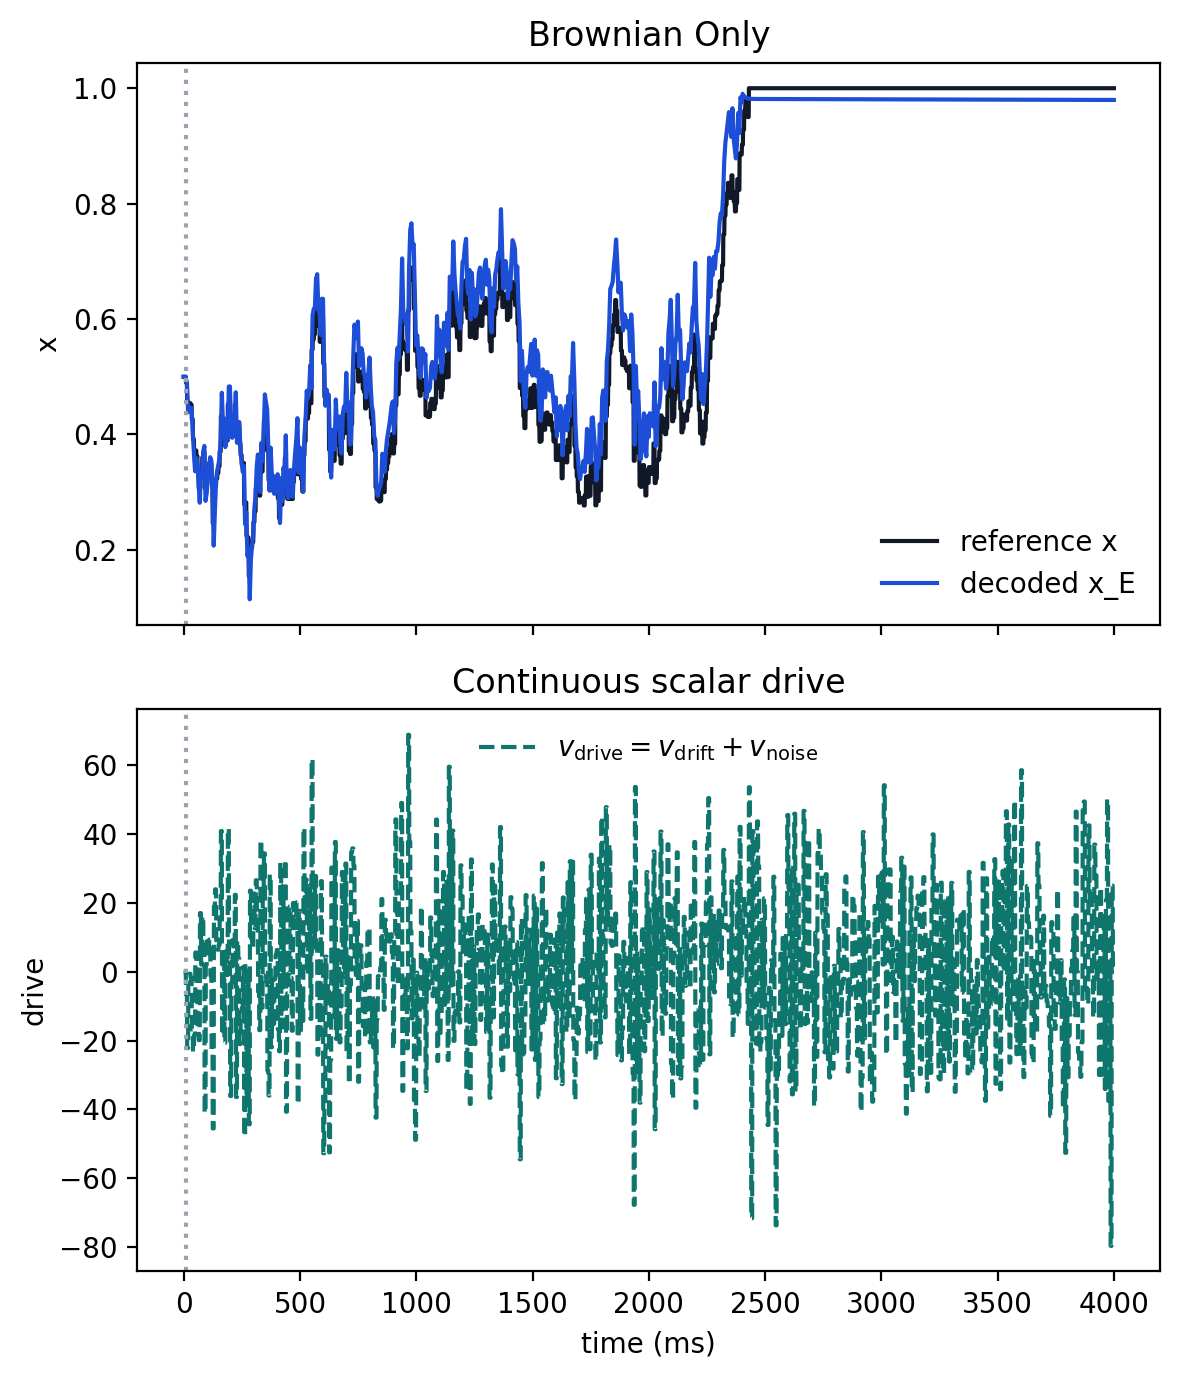

In [16]:
CASE_BROWNIAN = {
    "label": "Brownian Only",
    "seed": 300,
    "v": 0.0,
    "c": 0.5,
}
brownian = run_case(case=CASE_BROWNIAN, kappa=float(calibration["kappa"]))
plot_case(brownian)
brownian_summary = summarize_case(brownian, calibration)
brownian_summary


## Case 2: `v > 0`, `c = 0`

This is the deterministic-drift limit.


{'label': 'Deterministic Drift Only',
 'v': 1.0,
 'c': 0.0,
 'mean_abs_error_xE': 0.014987038433701149,
 'mean_abs_error_xB': 0.017359876854975396,
 'alignment_mean_abs': 0.06009560450911522,
 'c_be_theta_max': 0.5382170012994668,
 'certificate_passed': True,
 'hit_boundary': True}

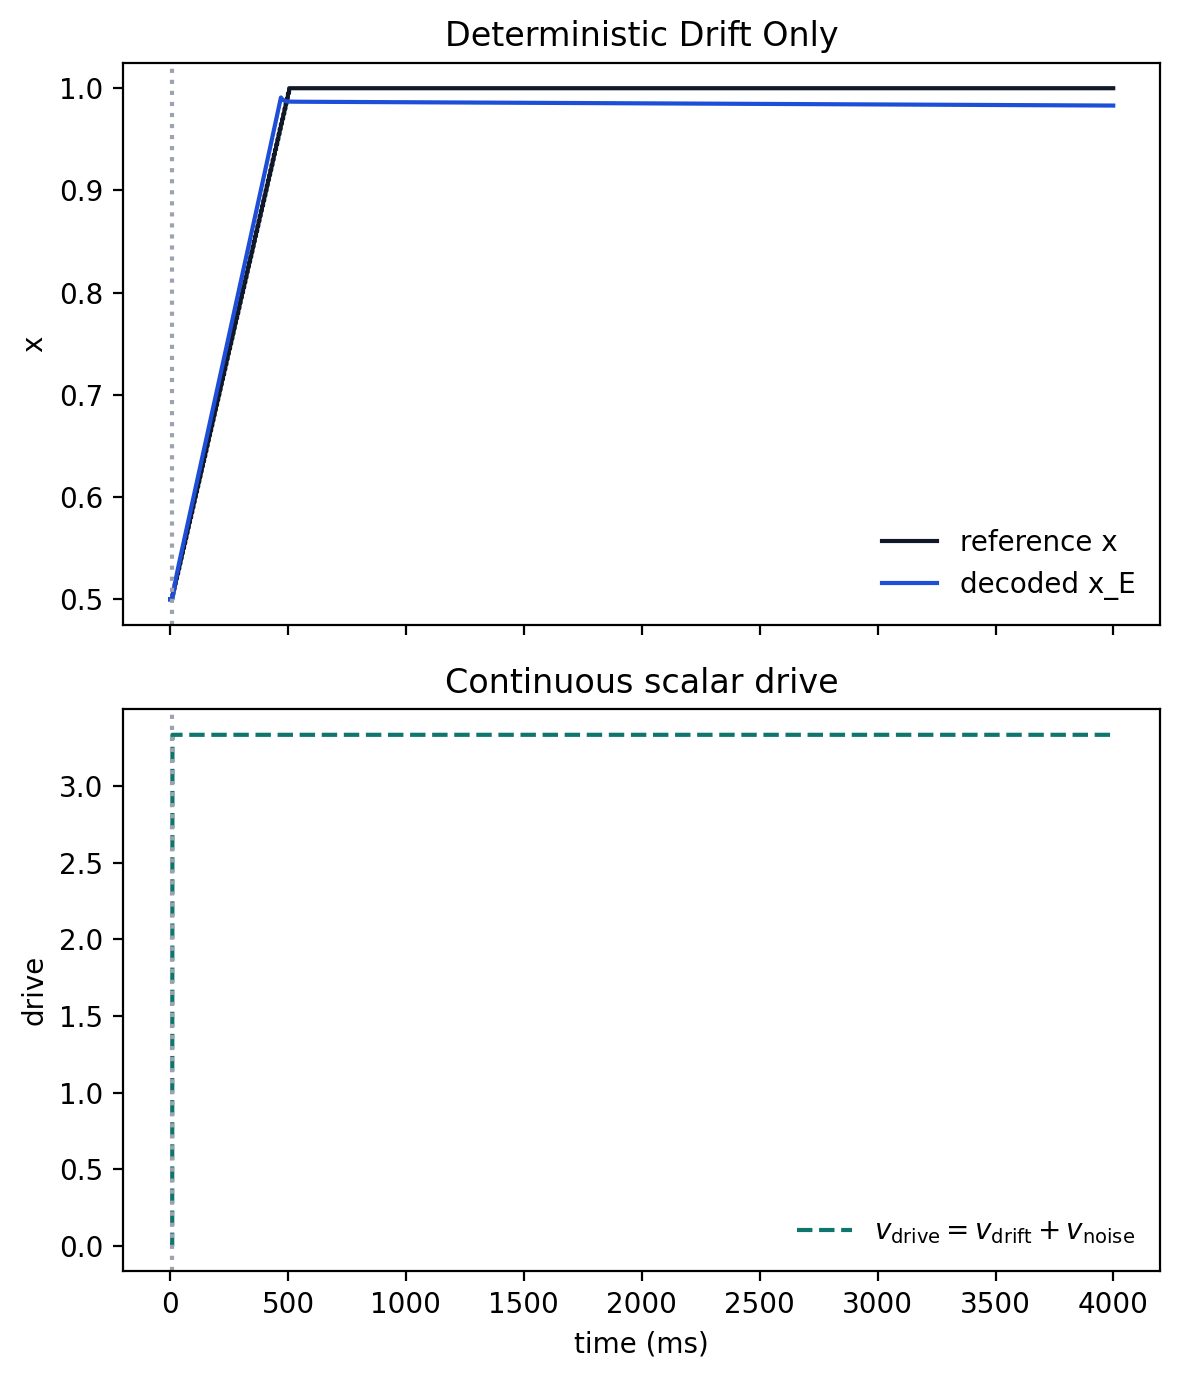

In [10]:
CASE_DRIFT = {
    "label": "Deterministic Drift Only",
    "seed": 321,
    "v": 1.0,
    "c": 0.0,
}


drift = run_case(case=CASE_DRIFT, kappa=float(calibration["kappa"]))
plot_case(drift)
drift_summary = summarize_case(drift, calibration)
drift_summary


## Case 3: `v = 3`, `c = 0.3`

This is a real DDM simulation.

{'label': 'DDM',
 'v': 1.0,
 'c': 0.5,
 'mean_abs_error_xE': 0.020854405958262365,
 'mean_abs_error_xB': 0.047904472741345516,
 'alignment_mean_abs': 0.3667953312397003,
 'c_be_theta_max': 0.5382170012994668,
 'certificate_passed': True,
 'hit_boundary': True}

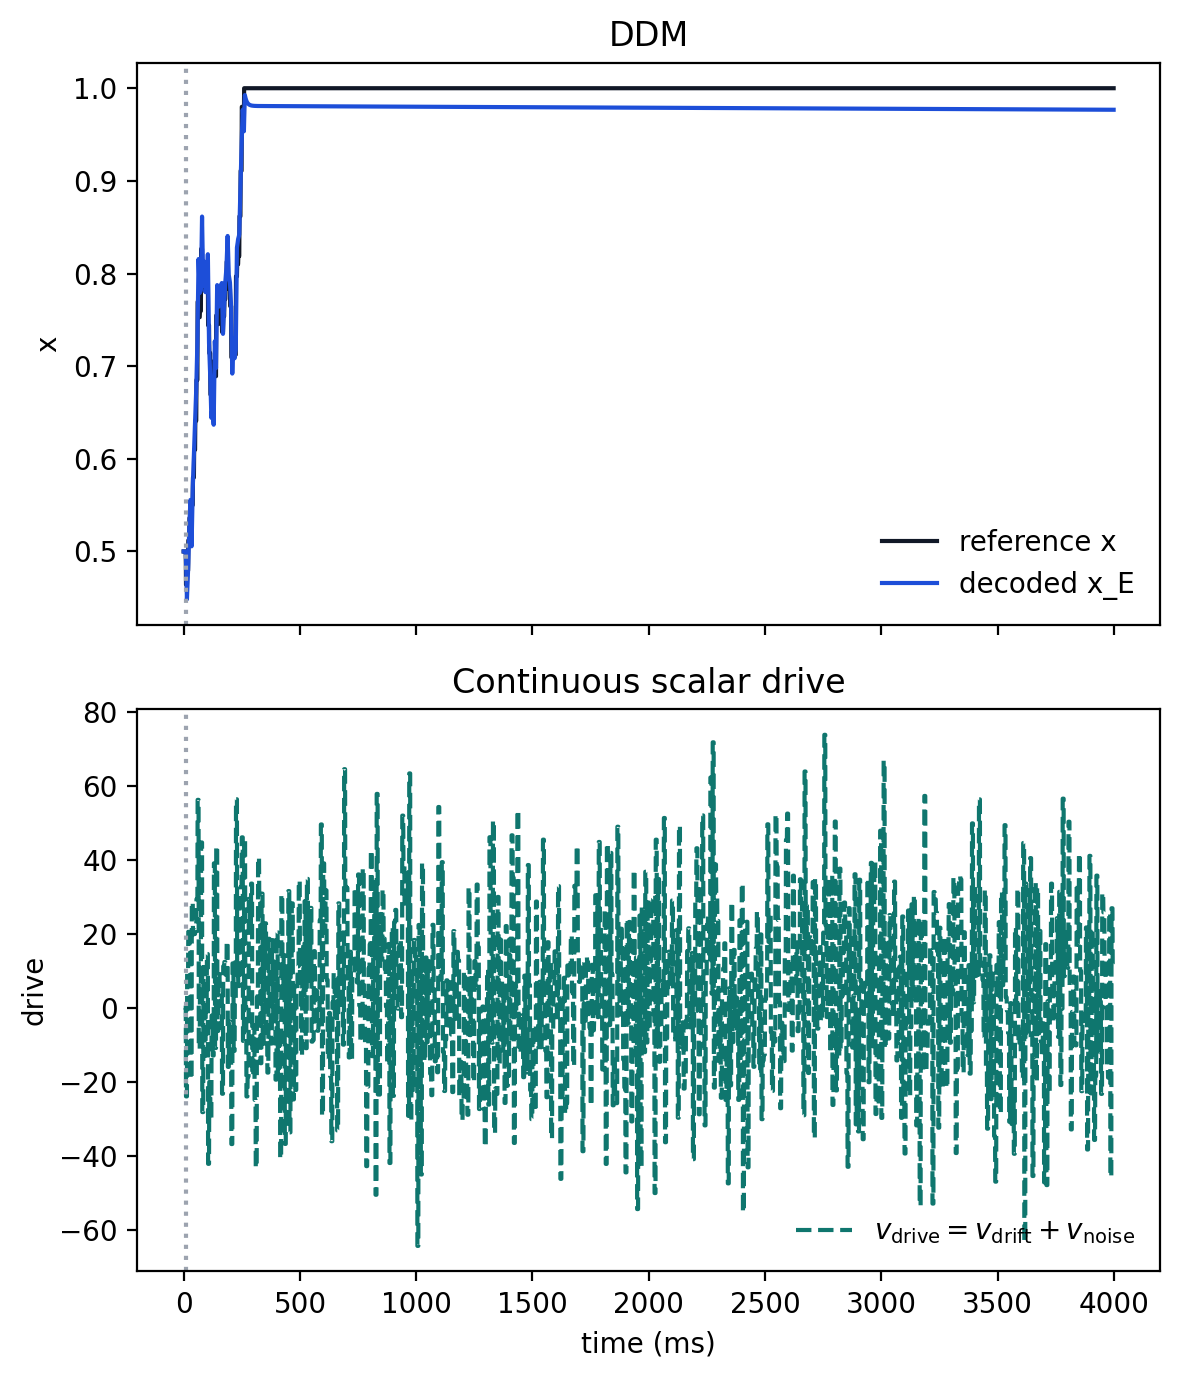

In [11]:
CASE_DDM = {
    "label": "DDM",
    "seed": 100,
    "v": 1,
    "c": 0.5,
}

DDM = run_case(case=CASE_DDM, kappa=float(calibration["kappa"]))
plot_case(DDM)
drift_summary = summarize_case(DDM, calibration)
drift_summary

In [12]:
DDM['RT']

253.0

## Notes

- This notebook intentionally keeps only the two single-trial checks.
- The Brownian and deterministic cases share one calibration call to reduce runtime and avoid unnecessary JAX/XLA stress.
- The next step after this notebook is the combined case `dx = v \, dt + c \, dW`.
